In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
order_payments = pd.read_csv("../../data/raw/olist_order_payments_dataset.csv")

In [5]:
order_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [6]:
order_payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [7]:
order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [8]:
order_payments["order_id"].nunique()

99440

In [9]:
order_payments["order_id"].duplicated().sum()

np.int64(4446)

In [10]:
order_payments["order_id"].value_counts().head(20)

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
ee9ca989fc93ba09a6eddc250ce01742    19
fedcd9f7ccdc8cba3a18defedd1a5547    19
21577126c19bf11a0b91592e5844ba78    15
4bfcba9e084f46c8e3cb49b0fa6e6159    15
3c58bffb70dcf45f12bdf66a3c215905    14
4689b1816de42507a7d63a4617383c59    14
4fb76fa13b108a0d0478483421b0992c    13
cf101c3abd3c061ca9f78c1bbb1125af    13
73df5d6adbeea12c8ae03df93f346e86    13
68986e4324f6a21481df4e6e89abcf01    12
1d9a9731b9c10fc9cba74e6f74782e8b    12
c6492b842ac190db807c15aff21a7dd6    12
6d58638e32674bebee793a47ac4cbadc    12
d744783ed2ace06cac647a9e64dcbcfd    12
67d83bd36ec2c7fb557742fb58837659    12
1a611328643ae11146ba09a4425d2e12    12
Name: count, dtype: int64

In [11]:
payment_type_count = order_payments["payment_type"].value_counts()
payment_type_count

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [12]:
order_payments["payment_type"].value_counts(normalize=True)*100 #gives percent of most used payment type

payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64

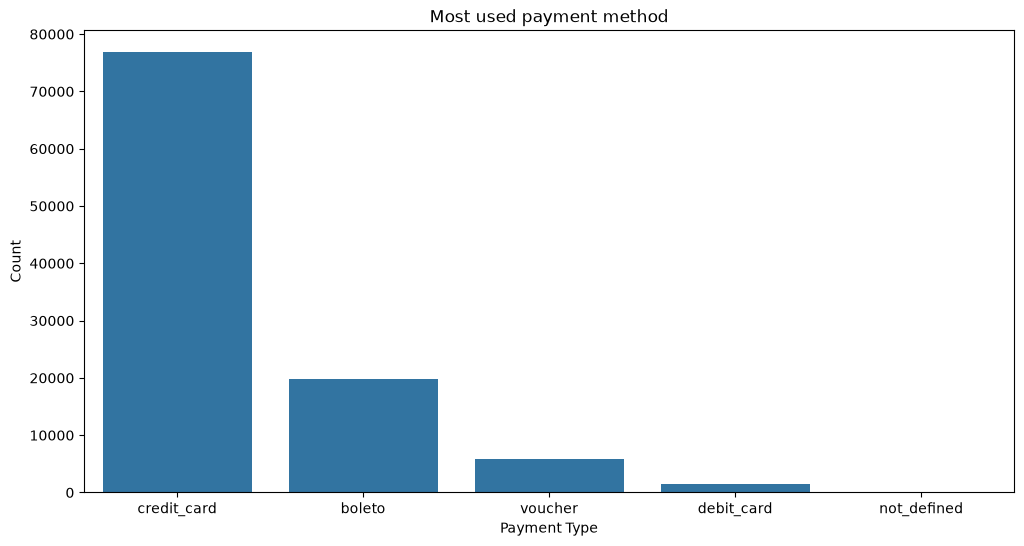

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(x=payment_type_count.index, y=payment_type_count.values)
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.title("Most used payment method")
plt.savefig("../../output/charts/payments/payment_type_count.png",dpi=300)
plt.show()

In [14]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [45]:
order_payments["payment_sequential"].value_counts()

payment_sequential
1     99360
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
17        6
19        6
16        6
18        6
21        4
20        4
22        3
25        2
26        2
24        2
23        2
27        1
29        1
28        1
Name: count, dtype: int64

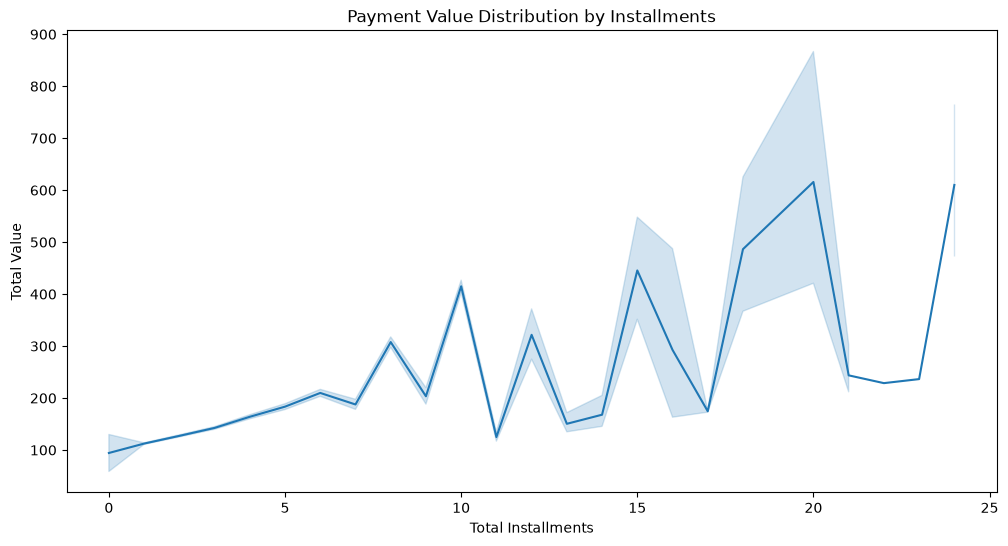

In [18]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=order_payments,
    x="payment_installments",
    y="payment_value"
)
plt.xlabel('Total Installments')
plt.ylabel("Total Value")
plt.title("Payment Value Distribution by Installments")
plt.savefig("../../output/charts/payments/Payment_Value_Distribution_by_Installments",dpi=300)
plt.show()

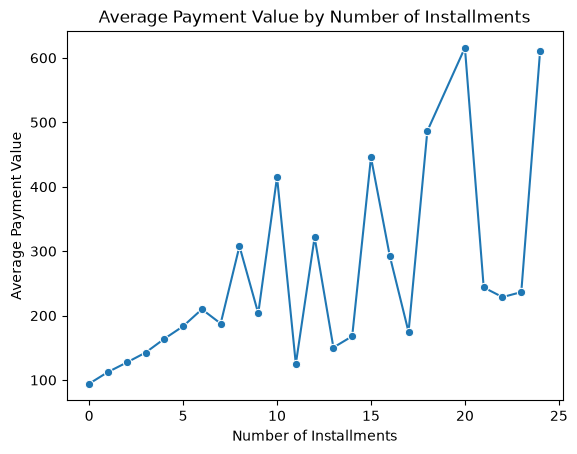

In [20]:
avg_payment = (
    order_payments
    .groupby("payment_installments")["payment_value"]
    .mean()
)

sns.lineplot(
    x=avg_payment.index,
    y=avg_payment.values,
    marker="o"
)

plt.xlabel("Number of Installments")
plt.ylabel("Average Payment Value")
plt.title("Average Payment Value by Number of Installments")
plt.savefig("../../output/charts/payments/average_payment_value_by_number_of_installments",dpi=300)
plt.show()

In [22]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


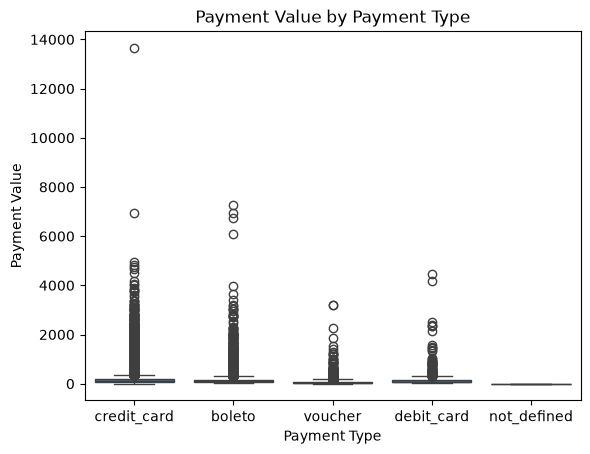

In [27]:
sns.boxplot(
    data=order_payments,
    x="payment_type",
    y="payment_value"
)

plt.title("Payment Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Payment Value")
plt.savefig("../../output/charts/payments/payment_value_by_payment_type",dpi=300)
plt.show()

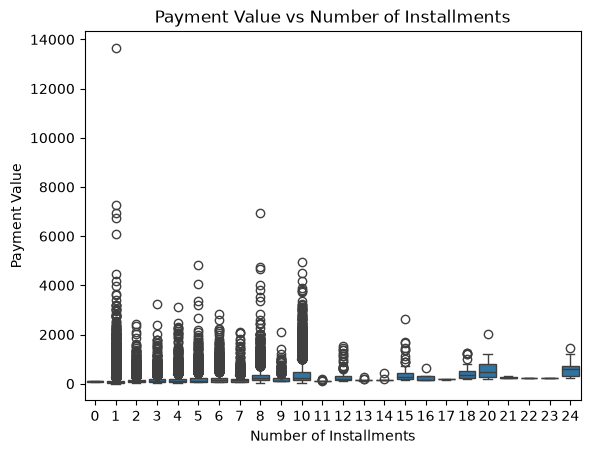

In [26]:
sns.boxplot(
    data=order_payments,
    x="payment_installments",
    y="payment_value"
)


plt.title("Payment Value vs Number of Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Payment Value")
plt.savefig("../../output/charts/payments/payment_value_by_installments",dpi=300)
plt.show()

In [28]:
order_payments.groupby("payment_installments")["payment_value"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
payment_installments,,,
0,2,94.315000,94.315
1,52546,112.420229,73.340
2,12413,127.228150,109.420
3,10461,142.539317,110.420
4,7098,163.976840,117.175
5,5239,183.465222,125.970
6,3920,209.849952,138.550
7,1626,187.673672,140.075
8,4268,307.737427,212.695


In [29]:
payment_installment = pd.crosstab(
    order_payments["payment_type"],
    order_payments["payment_installments"]
)

payment_installment

payment_installments,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,20,21,22,23,24
payment_type,,,,,,,,,,,,,,,,,,,,,
boleto,0,19784,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
credit_card,2,25455,12413,10461,7098,5239,3920,1626,4268,644,...,15,74,5,8,27,17,3,1,1,18
debit_card,0,1529,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
not_defined,0,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
voucher,0,5775,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


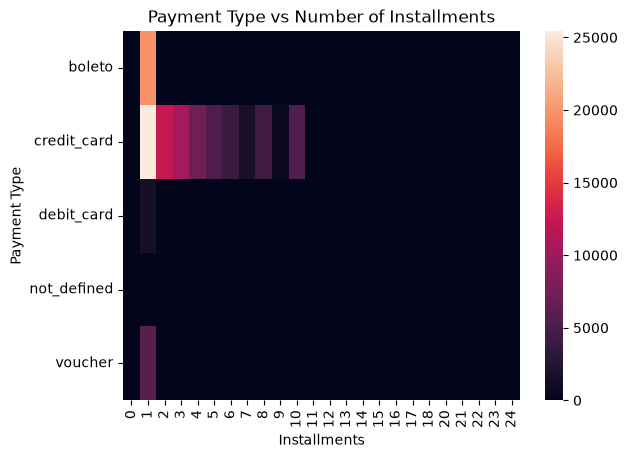

In [33]:
sns.heatmap(
    payment_installment,
)

plt.title("Payment Type vs Number of Installments")
plt.xlabel("Installments")
plt.ylabel("Payment Type")
plt.savefig("../../output/charts/payments/payment_type_and_installment",dpi=300)
plt.show()

In [37]:
order_payment_summary = (
    order_payments
    .groupby("order_id")
    .agg(
        payment_count=("payment_sequential", "count"),
        total_payment=("payment_value", "sum")
    )
    .reset_index()
)


In [39]:
order_payment_summary


,order_id,payment_count,total_payment
0,00010242fe8c5a6d1ba2dd792cb16214,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,259.83
2,000229ec398224ef6ca0657da4fc703e,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,218.04
...,...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,1,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,1,386.53
99437,fffce4705a9662cd70adb13d4a31832d,1,116.85
99438,fffe18544ffabc95dfada21779c9644f,1,64.71


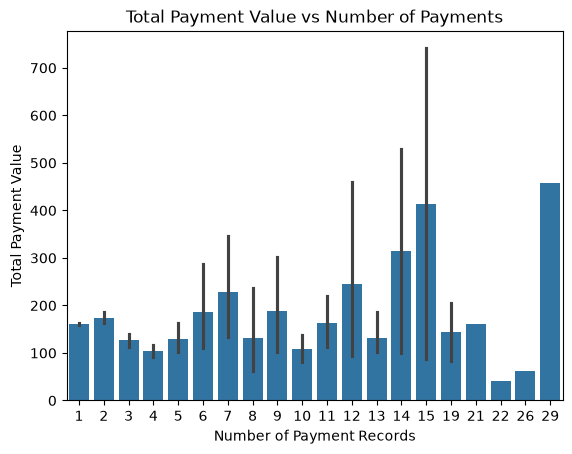

In [43]:
sns.barplot(
    data=order_payment_summary,
    x="payment_count",
    y="total_payment"
)

plt.xlabel("Number of Payment Records")
plt.ylabel("Total Payment Value")
plt.title("Total Payment Value vs Number of Payments")
plt.savefig("../../output/charts/payments/total_value_vs_payment",dpi=300)
plt.show()

In [52]:
order_payments.corr(numeric_only=True)


,payment_sequential,payment_installments,payment_value
payment_sequential,1.000000,-0.086363,-0.069593
payment_installments,-0.086363,1.000000,0.330811
payment_value,-0.069593,0.330811,1.000000


In [55]:
order_payments["payment_installments"].corr(order_payments["payment_value"])


np.float64(0.3308108445189853)

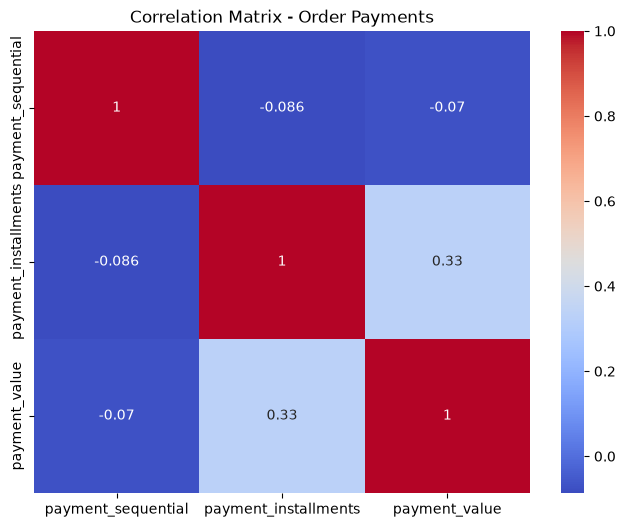

In [56]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    order_payments.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix - Order Payments")
plt.show()

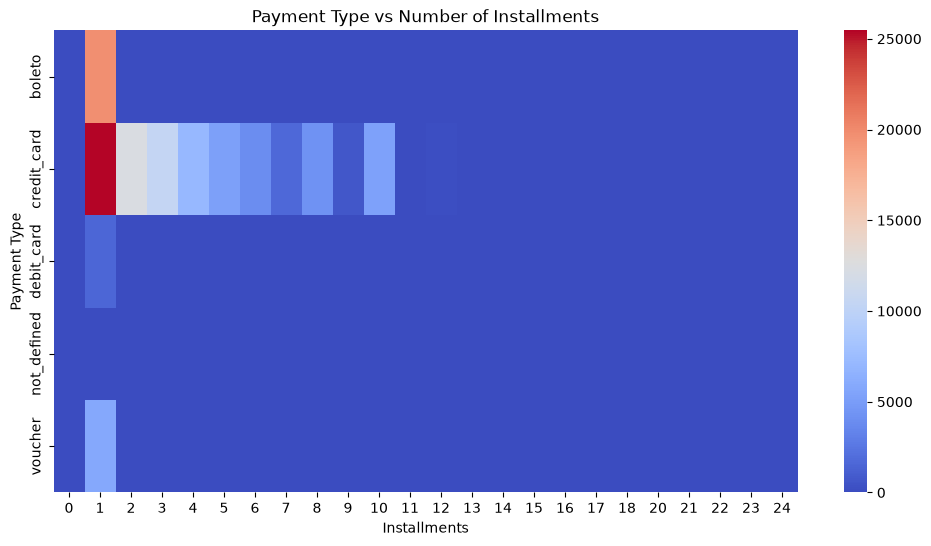

In [69]:
payment_installment = pd.crosstab(
    order_payments["payment_type"],
    order_payments["payment_installments"]
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    payment_installment,
    cmap="coolwarm",


)

plt.title("Payment Type vs Number of Installments")
plt.xlabel("Installments")
plt.ylabel("Payment Type")

plt.show()

## Key Observations

### 1. Payment Installments

- The number of payment installments ranges from **0 to 24**, with an average of approximately **2.68 installments**.
- The majority of payments are concentrated around a relatively small number of installments, indicating that customers generally prefer shorter installment plans.

### 2. Payment Value

- The recorded payment value ranges from **0 to 13,664**, with an average payment value of approximately **154.10**.
- The wide range between the minimum and maximum values indicates considerable variation in order payment amounts.

### 3. Payment Method Distribution

- The dataset contains **5 unique payment methods**.
- **Credit card** is the most commonly used payment method, accounting for approximately **73.92% of payment records/orders**.
- This indicates a strong preference for credit-card payments among customers in the dataset.

### 4. Payment Sequence

- Approximately **95.64% of orders have a single payment sequence** (`payment_sequential = 1`).
- This indicates that the vast majority of orders are completed using a single payment record, while only a small proportion involve multiple payment sequences.

### 5. Product/Payment Value vs Installments

- A **positive Pearson correlation of approximately 0.33** was observed between payment value and the number of installments.
- This indicates a **weak-to-moderate positive linear relationship**: higher-value payments tend to be associated with a greater number of installments.
- However, the correlation is not strong enough to suggest that payment value alone determines the number of installments.

### 6. Payment Method vs Payment Value

- Further analysis indicates that **higher-value payments show a greater tendency to be associated with credit-card payments**.
- This suggests that customers making larger purchases may be more likely to use credit cards, potentially because credit cards support installment-based payments.

### 7. Payment Method and Installment Relationship

- **Credit card is the only payment method with meaningful installment usage**, with customers using installment plans ranging from 2 to 24 installments.
- Although credit-card payments account for most installment activity, **single-payment transactions remain the dominant pattern**, including among credit-card users.
- The other payment methods — **boleto, debit card, and voucher** — are effectively limited to a single installment, which is consistent with their payment structure.
- Installment usage shows some variation across higher installment counts rather than a simple declining trend, suggesting that specific installment plans may be influenced by **purchase value or promotional financing options**.
- Overall, installment-based payment analysis is therefore largely a **credit-card-specific behavior** in this dataset.

### Overall Insight

Overall, the payment data suggests that customers predominantly use **credit cards and single-payment transactions**, while installment-based payments become more common as payment values increase. The moderate positive relationship between payment value and installments provides evidence that customers may use installment plans more frequently for higher-value purchases.

